# 📊 Project: End-to-End FinTech Transaction Analysis

## 1. Introduction
The primary objective of this project is to analyze a transaction dataset from an emerging FinTech Company using Python-based data analysis tools and create a visually interactive Tableau dashboard for the stakeholders.


In [1]:
# -------------------------------
# 2. Import Libraries
# -------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

plt.style.use("seaborn-v0_8")
sns.set_palette("muted")

## 2. Load Dataset
We begin by loading the MaddoxPay transaction dataset.  
The dataset is assumed to contain the following columns:

- Transaction_ID  
- Date  
- Customer_ID  
- Merchant_Name  
- Transaction_Amount  
- Payment_Method  
- Transaction_Status  
- Location  

Then we also see basic information of the dataset like its shape, columns, column descriptions etc.


In [2]:
# Load your dataset
df = pd.read_csv("fintech_transactions_2025_full_year_final.csv")

# Quick look
print("Shape:", df.shape)

print("Columns:", df.columns)

print(df.head(10))

#column info
df.info()

#summary
df.describe()



Shape: (1625, 8)
Columns: Index(['Transaction_ID', 'Date', 'Customer_ID', 'Merchant_Name',
       'Transaction_Amount', 'Payment_Method', 'Transaction_Status',
       'Location'],
      dtype='object')
  Transaction_ID        Date Customer_ID Merchant_Name  Transaction_Amount  \
0          T1000  2025-01-01        C142      Flipkart             3617.79   
1          T1001  2025-01-01        C111        Myntra              977.59   
2          T1002  2025-01-01        C181        Amazon              363.17   
3          T1003  2025-01-01        C104        Myntra             4366.30   
4          T1004  2025-01-01        C178        Myntra              132.61   
5          T1005  2025-01-01        C199        Amazon             3881.97   
6          T1006  2025-01-02        C135      Flipkart             1145.31   
7          T1007  2025-01-02        C144      Flipkart             4913.71   
8          T1008  2025-01-02        C130        Swiggy             4953.97   
9          T1009  

,Transaction_Amount
count,1625.000000
mean,3414.176302
std,2390.949343
min,53.350000
25%,1543.740000
50%,3075.980000
75%,4631.640000
max,9988.410000


## 3. Data Cleaning
- Convert date column to datetime format.  
- Drop duplicates.  
- Handle missing values.  

In [3]:
# 0) Basic Data Cleaning

# 1. Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# 2. Drop rows with missing critical values
df.dropna(subset=['Transaction_ID', 'Date', 'Customer_ID', 'Merchant_Name', 'Transaction_Amount', 'Payment_Method', 'Transaction_Status'], inplace=True)

# 3. Remove duplicates based on Transaction_ID
df.drop_duplicates(subset=['Transaction_ID'], inplace=True)

# 4. Ensure data types are correct
df['Transaction_Amount'] = pd.to_numeric(df['Transaction_Amount'], errors='coerce')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# 5. Remove transactions with negative or zero amounts
df = df[df['Transaction_Amount'] > 0]

# 6. Optional: Strip whitespace from strings
string_cols = ['Transaction_ID', 'Customer_ID', 'Merchant_Name', 'Payment_Method', 'Transaction_Status', 'Location']
for col in string_cols:
    df[col] = df[col].str.strip()

# 7. Check cleaned data
print("Data after cleaning:")
print(df.info())
print(df.head())


Missing values per column:
Transaction_ID        0
Date                  0
Customer_ID           0
Merchant_Name         0
Transaction_Amount    0
Payment_Method        0
Transaction_Status    0
Location              0
dtype: int64
Data after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1625 entries, 0 to 1624
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Transaction_ID      1625 non-null   object        
 1   Date                1625 non-null   datetime64[ns]
 2   Customer_ID         1625 non-null   object        
 3   Merchant_Name       1625 non-null   object        
 4   Transaction_Amount  1625 non-null   float64       
 5   Payment_Method      1625 non-null   object        
 6   Transaction_Status  1625 non-null   object        
 7   Location            1625 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 101.7+ KB
None
  T

## 4. Key Metrics
We calculate some important KPIs:
- Total transactions  
- Total transaction value  
- Average transaction value  
- Success rate  

In [4]:
total_txn = df['Transaction_ID'].nunique()
total_value = df['Transaction_Amount'].sum()
avg_value = df['Transaction_Amount'].mean()
success_rate = (df['Transaction_Status'].value_counts(normalize=True)['Success']) * 100

print("Total Transactions:", total_txn)
print("Total Value: ₹", round(total_value,2))
print("Average Transaction Value: ₹", round(avg_value,2))
print("Success Rate:", round(success_rate,2), "%")

Total Transactions: 1625
Total Value: ₹ 5548036.49
Average Transaction Value: ₹ 3414.18
Success Rate: 83.2 %


## 5. Daily Transaction Value Trend
We analyze the daily transaction values to see how transaction values changes with time.

/tmp/ipykernel_2008/3478884930.py:10: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_2008/3478884930.py:11: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.savefig("Daily Transaction Value Trend", dpi=300)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


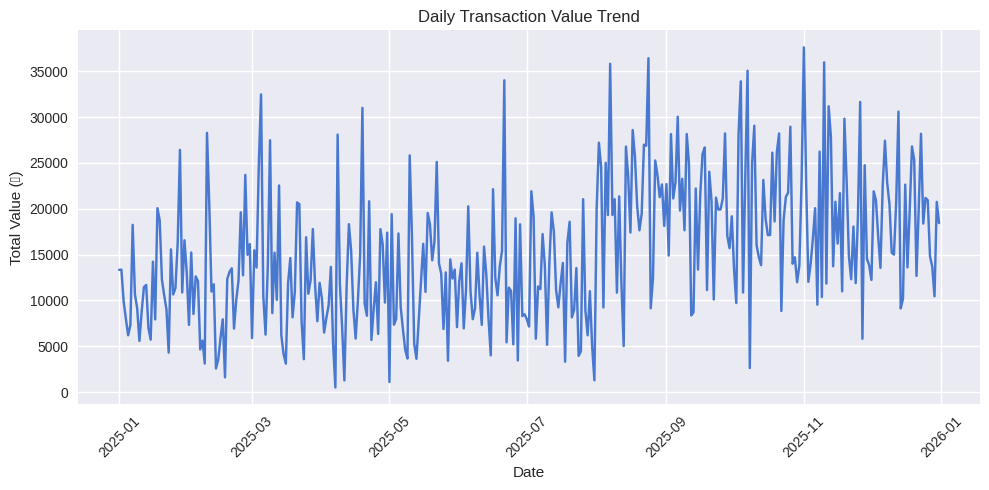

In [5]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
txn_trend = df.groupby(df['Date'].dt.date)['Transaction_Amount'].sum()

plt.figure(figsize=(10,5))
txn_trend.plot(kind='line')
plt.title("Daily Transaction Value Trend")
plt.xlabel("Date")
plt.ylabel("Total Value (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Daily Transaction Value Trend", dpi=300)
plt.show()

## 6. Daily Transaction Count Trend

We analyze the daily transaction count to see how transaction frequency changes with time.

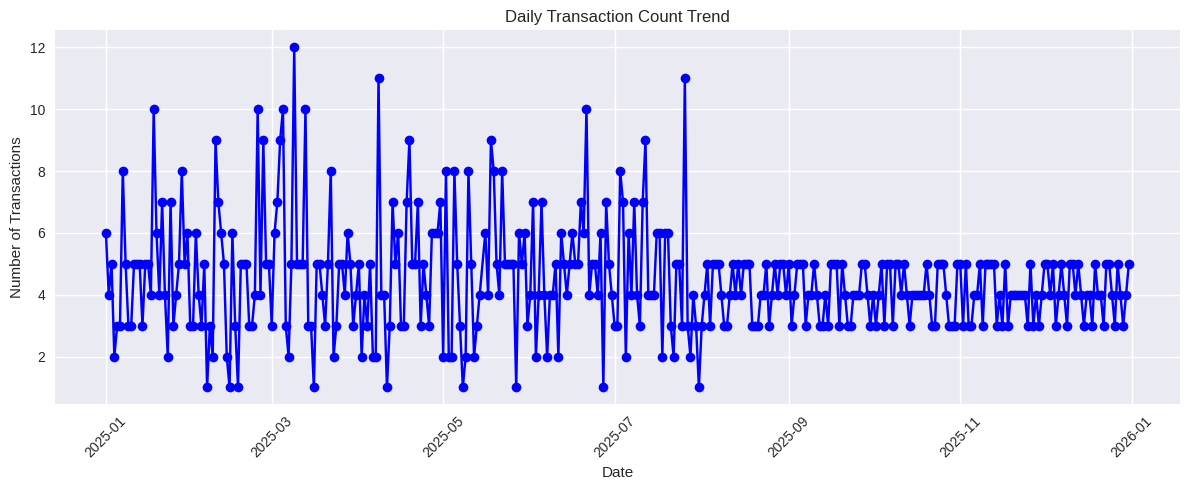

In [6]:
# Group by date and count transactions
daily_count = df.groupby(df['Date'].dt.date)['Transaction_ID'].count()

# Plot daily transaction count
fig, ax = plt.subplots(figsize=(12,5))
daily_count.plot(kind='line', marker='o', color='blue', ax=ax, title='Daily Transaction Count Trend')

plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Daily Transaction Count Trend", dpi=300)
plt.show()


## 7. Monthly Transaction Value Trend

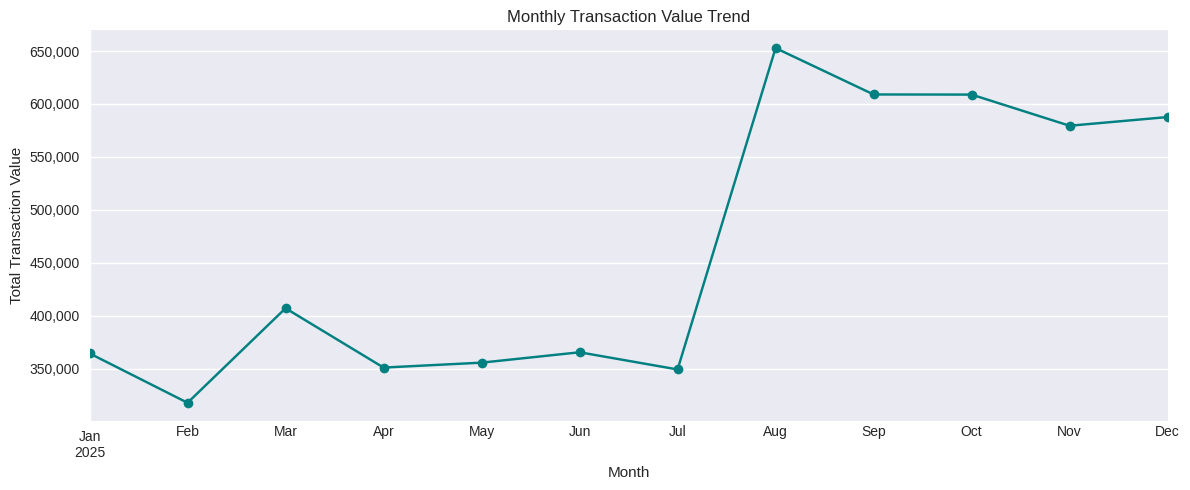

In [7]:
# Create a month column (Year-Month)
df['Month'] = df['Date'].dt.to_period('M')

# Aggregate monthly transaction values
monthly_value = df.groupby('Month')['Transaction_Amount'].sum()

# Plot monthly transaction values
fig, ax = plt.subplots(figsize=(12,5))
monthly_value.plot(kind='line', marker='o', color='teal', ax=ax, title='Monthly Transaction Value Trend')

# Format y-axis with commas
import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.xlabel('Month')
plt.ylabel('Total Transaction Value')
plt.tight_layout()
plt.savefig("Monthly Transaction Value Trend", dpi=300)
plt.show()


## 8. Monthly Transaction Count Trend

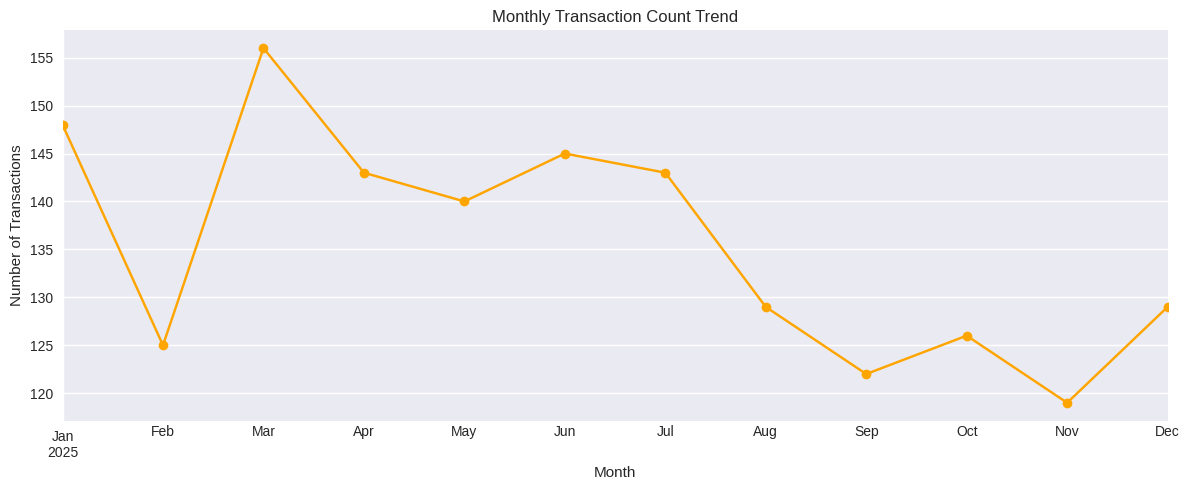

In [8]:
# Aggregate monthly transaction counts
monthly_count = df.groupby('Month')['Transaction_ID'].count()

# Plot monthly transaction counts
fig, ax = plt.subplots(figsize=(12,5))
monthly_count.plot(kind='line', marker='o', color='orange', ax=ax, title='Monthly Transaction Count Trend')

plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.savefig("Monthly Transaction Count Trend", dpi=300)
plt.show()


## 9. Quarterly Transaction Value Bar Graph


/tmp/ipykernel_2008/4111191951.py:9: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_value = df.groupby(pd.Grouper(key="Date", freq="Q")).agg(


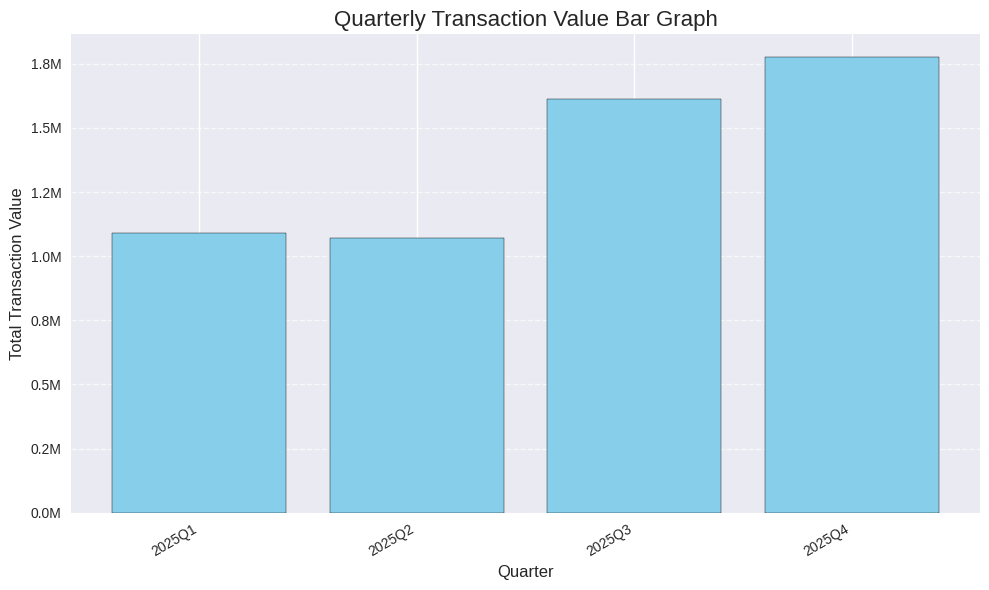

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mticker

# Ensure Date is datetime
df["Date"] = pd.to_datetime(df["Date"])

# Group by quarter for transaction value
quarterly_value = df.groupby(pd.Grouper(key="Date", freq="Q")).agg(
    Total_Value=("Transaction_Amount", "sum")
).reset_index()

# Plot bar chart
plt.figure(figsize=(10,6))
plt.bar(quarterly_value["Date"].dt.to_period("Q").astype(str),
        quarterly_value["Total_Value"],
        color="skyblue", edgecolor="black")

plt.title("Quarterly Transaction Value Bar Graph", fontsize=16)
plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Total Transaction Value", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Format y-axis to show values in millions instead of 1e6
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig("Quarterly Transaction Value Bar Graph", dpi=300)
plt.show()


## 10. Quarterly Transaction Count Bar Graph


/tmp/ipykernel_2008/1145391772.py:8: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_count = df.groupby(pd.Grouper(key="Date", freq="Q")).agg(


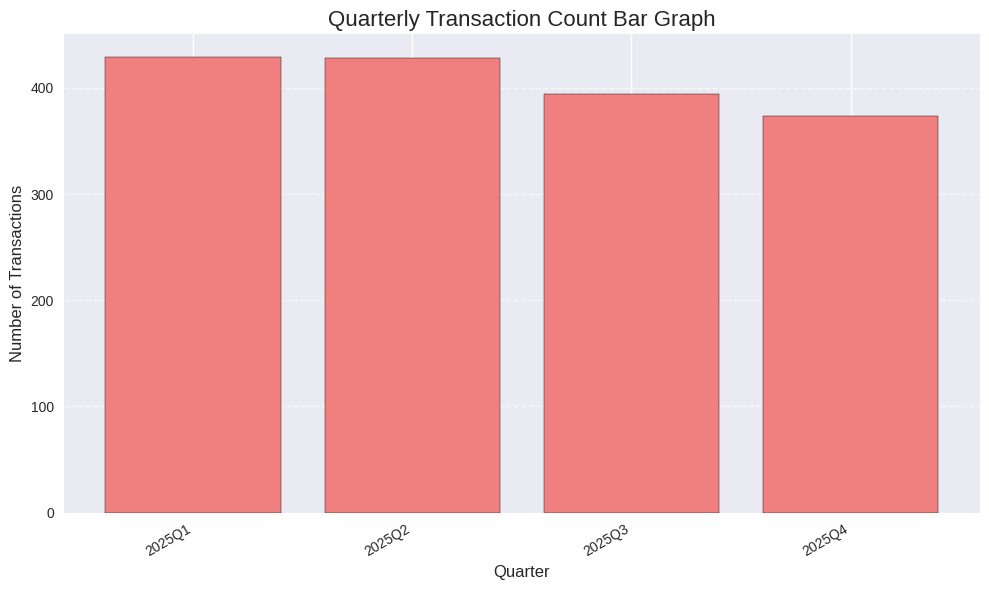

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure Date is datetime
df["Date"] = pd.to_datetime(df["Date"])

# Group by quarter for transaction count
quarterly_count = df.groupby(pd.Grouper(key="Date", freq="Q")).agg(
    Total_Transactions=("Transaction_ID", "count")
).reset_index()

# Plot bar chart
plt.figure(figsize=(10,6))
plt.bar(quarterly_count["Date"].dt.to_period("Q").astype(str),
        quarterly_count["Total_Transactions"],
        color="lightcoral", edgecolor="black")

plt.title("Quarterly Transaction Count Bar Graph", fontsize=16)
plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("Quarterly Transaction Count Bar Graph", dpi=300)
plt.show()


## 11. Payment Method Analysis Pie Chart (by number of transactions)
Understanding which payment methods are most popular among customers by number of transactions.

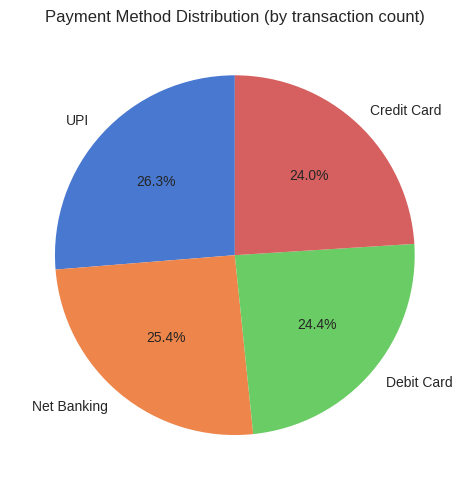

In [11]:
plt.figure(figsize=(7,5))
df['Payment_Method'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Payment Method Distribution (by transaction count)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("Payment Method Analysis Pie Chart(by number of transactions)", dpi=300)
plt.show()

## 12. Payment Method Analysis Pie Chart (by transaction value)
Understanding which payment methods are most popular among customers by transaction value.

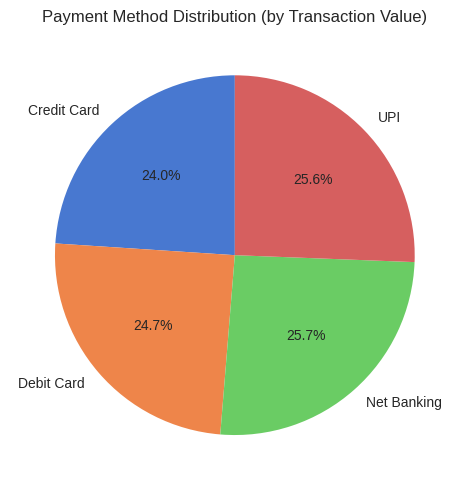

In [12]:
plt.figure(figsize=(7,5))

df.groupby("Payment_Method")["Transaction_Amount"].sum().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Method Distribution (by Transaction Value)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("Payment Method Analysis Pie Chart (by transaction value).png", dpi=300)
plt.show()

##13. Location-wise Bar Graph – Transaction Value

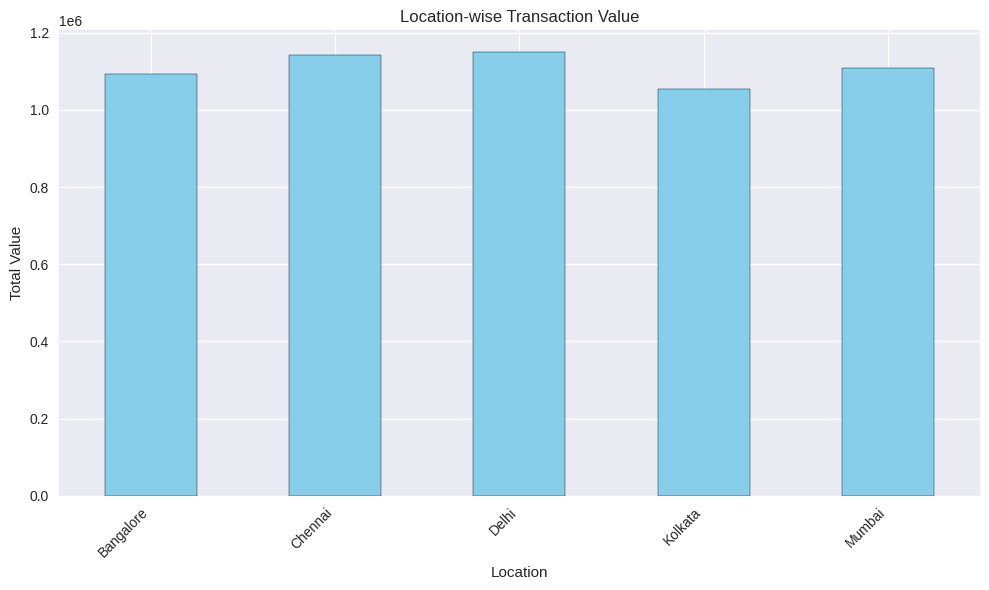

In [13]:
df.groupby("Location")["Transaction_Amount"].sum().plot.bar(
    figsize=(10,6), color="skyblue", edgecolor="black"
)
plt.title("Location-wise Transaction Value")
plt.xlabel("Location")
plt.ylabel("Total Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("Location-wise Bar Graph – Transaction Value", dpi=300)
plt.show()


## 14. Location-wise Bar Graph – Transaction Count

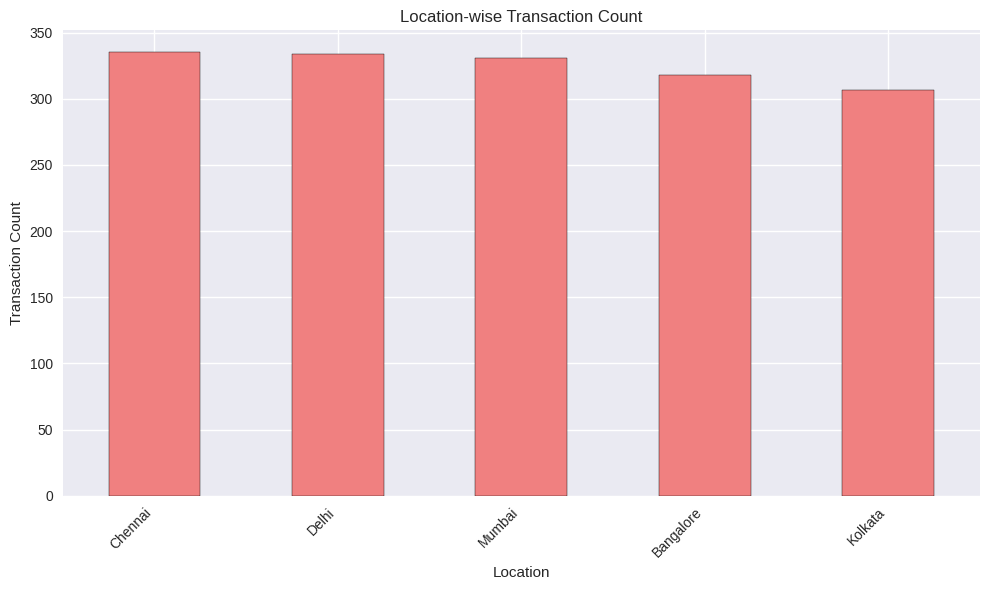

In [14]:
df["Location"].value_counts().plot.bar(
    figsize=(10,6), color="lightcoral", edgecolor="black"
)
plt.title("Location-wise Transaction Count")
plt.xlabel("Location")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("Location-wise Bar Graph – Transaction Count", dpi=300)
plt.show()


## 15. Transaction Status Pie Chart
We check the success vs failure distribution of transactions.

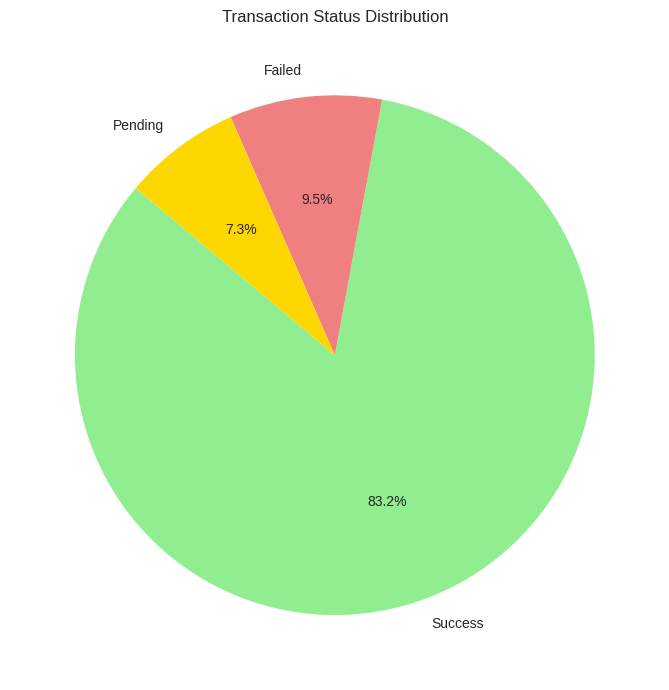

In [15]:
df["Transaction_Status"].value_counts().plot.pie(
    autopct="%1.1f%%", figsize=(7,7), startangle=140, colors=["lightgreen","lightcoral","gold"]
)
plt.title("Transaction Status Distribution")
plt.ylabel("")  # hides y-axis label
plt.tight_layout()
plt.savefig("Transaction Status Pie Chart", dpi=300)
plt.show()


## 16. Top 5 Merchants Bar Graph (transaction value)
We identify the top 5 merchants by total transaction value.

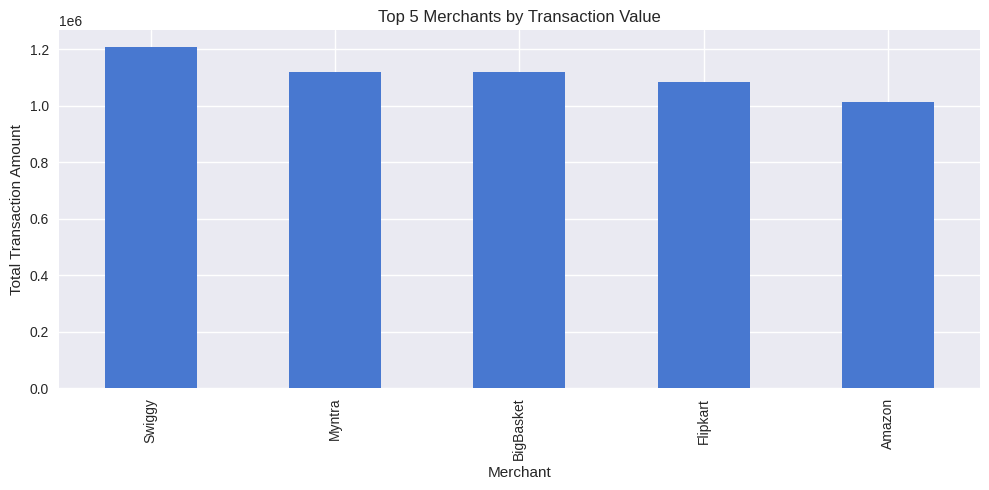

In [16]:
top_merchants1 = df.groupby('Merchant_Name')['Transaction_Amount'].sum().sort_values(ascending=False).head(10)
top_merchants1.plot(kind='bar', figsize=(10,5), title='Top 5 Merchants by Transaction Value')
plt.xlabel('Merchant')
plt.ylabel('Total Transaction Amount')
plt.tight_layout()
plt.savefig("Top 5 Merchants Bar Graph (transaction value)", dpi=300)
plt.show()

## 17. Top 10 Customers Bar Graph (transaction value)
We identify the top 10 customers who contributed the most in terms of transaction value.

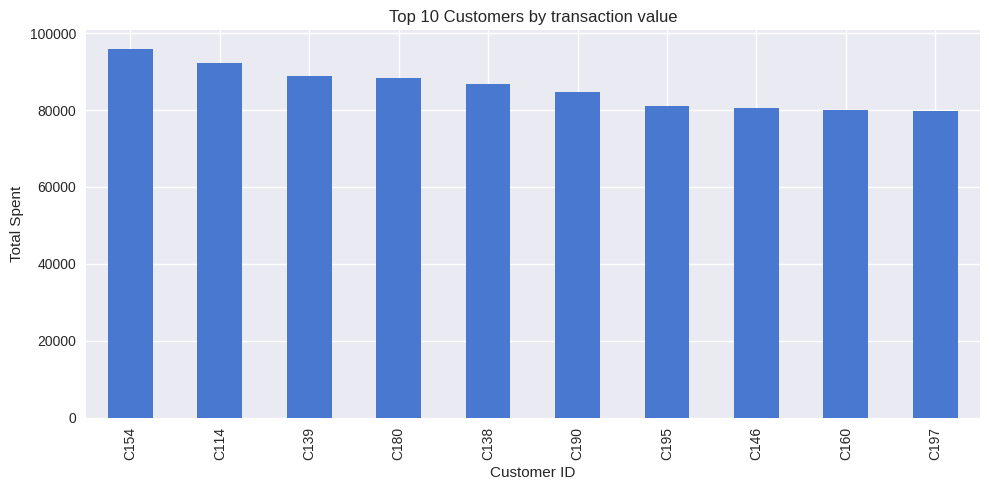

In [17]:
top_customers1 = df.groupby('Customer_ID')['Transaction_Amount'].sum().sort_values(ascending=False).head(10)
top_customers1.plot(kind='bar', figsize=(10,5), title='Top 10 Customers by transaction value')
plt.xlabel('Customer ID')
plt.ylabel('Total Spent')
plt.tight_layout()
plt.savefig("Top 10 Customers Bar Graph (transaction value)", dpi=300)
plt.show()

## 18. Top 5 Merchants Bar Graph (transaction count)

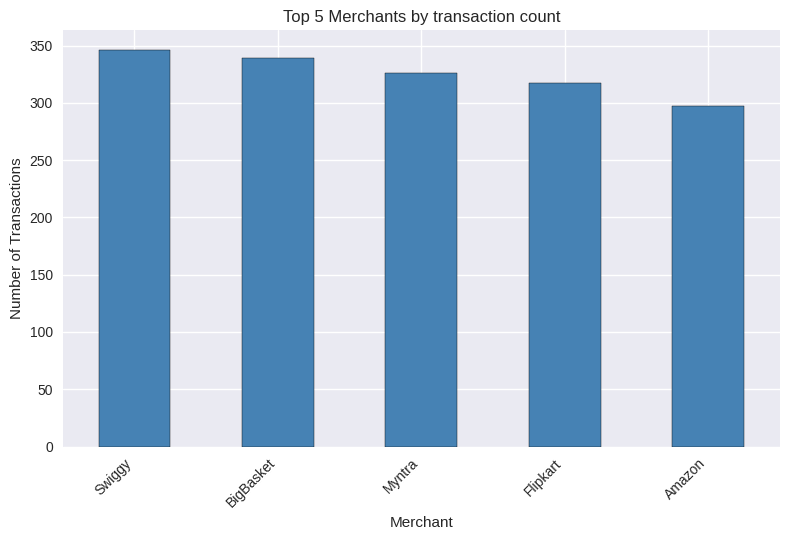

In [18]:
top_merchants2 = df["Merchant_Name"].value_counts().head(5)

# Bar chart
top_merchants2.plot.bar(color="steelblue", edgecolor="black")
plt.title("Top 5 Merchants by transaction count")
plt.xlabel("Merchant")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("Top 5 Merchants Bar Graph (transaction count)", dpi=300)
plt.show()


## 19. Top 10 Customers Bar Graph (transaction count)

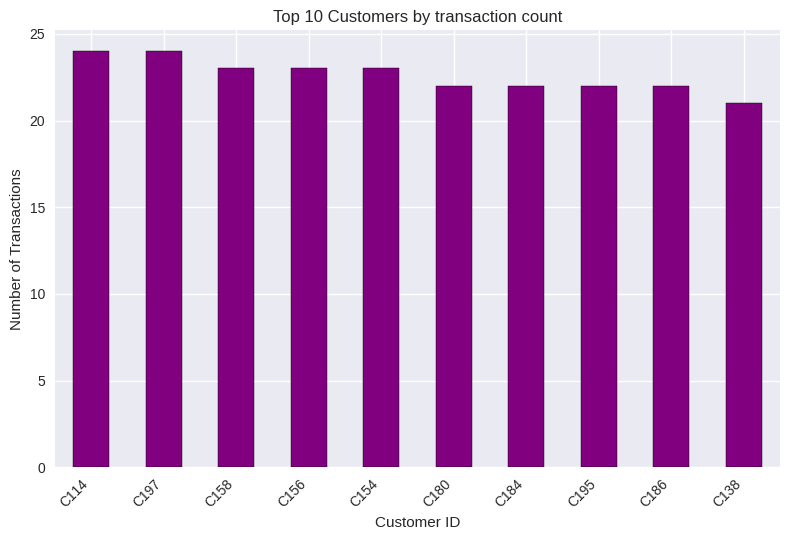

In [19]:
top_customers2 = df["Customer_ID"].value_counts().head(10)

top_customers2.plot.bar(color="purple", edgecolor="black")
plt.title("Top 10 Customers by transaction count")
plt.xlabel("Customer ID")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("Top 10 Customers Bar Graph (transaction count)", dpi=300)
plt.show()


## 20. High Value Transactions greater than 4000


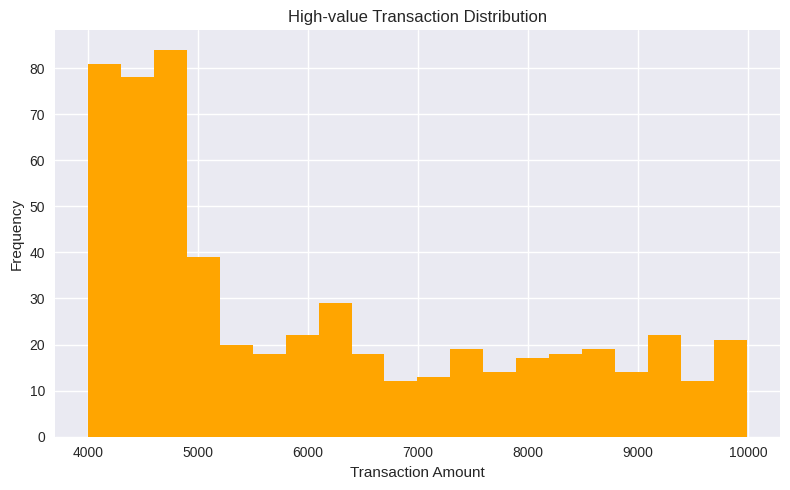

In [20]:
high_value = df[df['Transaction_Amount'] > 4000]
high_value['Transaction_Amount'].hist(bins=20, figsize=(8,5), color='orange')
plt.title('High-value Transaction Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig("High Value Transactions greater than 4000", dpi=300)
plt.show()

## 21. Failed Transaction Rate per Payment Method

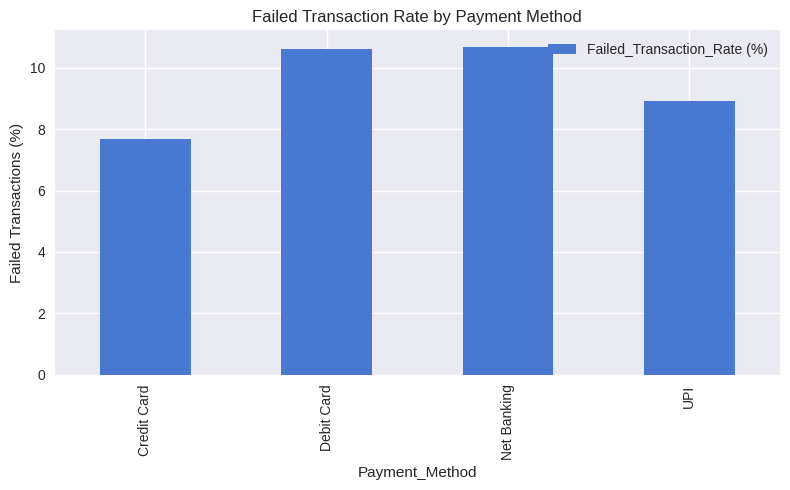

In [21]:

failed_rate = df[df['Transaction_Status'] == 'Failed'].groupby('Payment_Method').size() / df.groupby('Payment_Method').size() * 100

# Convert Series to DataFrame and rename the column
failed_rate = failed_rate.reset_index()
failed_rate.columns = ["Payment_Method", "Failed_Transaction_Rate (%)"]

# Plot
failed_rate.plot(
    x="Payment_Method",
    y="Failed_Transaction_Rate (%)",
    kind="bar",
    figsize=(8,5),
    title="Failed Transaction Rate by Payment Method"
)

plt.ylabel("Failed Transactions (%)")
plt.tight_layout()
plt.savefig("Failed Transaction Rate per Payment Method", dpi=300)
plt.show()

##22. Exporting the data of analysis in csv files


In [22]:
daily_summary = df.groupby(df["Date"].dt.date).agg(
    Total_Transactions=("Transaction_ID", "count"),
    Total_Value=("Transaction_Amount", "sum")
).reset_index()

daily_summary.columns = ["Date", "Total_Transactions", "Total_Value"]

daily_summary.to_csv("daily_summary.csv", index=False)


monthly_summary = df.groupby(df["Date"].dt.to_period("M")).agg(
    Total_Transactions=("Transaction_ID", "count"),
    Total_Value=("Transaction_Amount", "sum")
).reset_index()

monthly_summary.columns = ["Month", "Total_Transactions", "Total_Value"]

monthly_summary.to_csv("monthly_summary.csv", index=False)


quarterly_summary = df.groupby(pd.Grouper(key="Date", freq="Q")).agg(
    Total_Transactions=("Transaction_ID", "count"),
    Total_Value=("Transaction_Amount", "sum")
).reset_index()

quarterly_summary["Quarter"] = quarterly_summary["Date"].dt.to_period("Q").astype(str)
quarterly_summary = quarterly_summary[["Quarter", "Total_Transactions", "Total_Value"]]

quarterly_summary.to_csv("quarterly_summary.csv", index=False)


payment_summary = df.groupby("Payment_Method").agg(
    Total_Transactions=("Transaction_ID", "count"),
    Total_Value=("Transaction_Amount", "sum")
).reset_index()
payment_summary.to_csv('payment_summary.csv')

location_summary = df.groupby("Location").agg(
    Transaction_Count=("Transaction_ID", "count"),
    Total_Value=("Transaction_Amount", "sum")
).reset_index()

location_summary.to_csv("location_summary.csv", index=False)

status_summary = df["Transaction_Status"].value_counts().reset_index()
status_summary.columns = ["Transaction_Status", "Count"]
status_summary.to_csv('status_summary.csv')

top_customers = df.groupby("Customer_ID").agg(
    Total_Transactions=("Transaction_ID", "count"),
    Total_Value=("Transaction_Amount", "sum")
).reset_index()

# Sort by transaction count (or Total_Value if you prefer)
top_customers = top_customers.sort_values(
    by="Total_Transactions",
    ascending=False
).head(10)

top_customers.to_csv("top_customers.csv", index=False)


top_merchants = df.groupby("Merchant_Name").agg(
    Total_Transactions=("Transaction_ID", "count"),
    Total_Value=("Transaction_Amount", "sum")
).reset_index()

# Sort by transaction count (or Total_Value if you prefer)
top_merchants = top_merchants.sort_values(
    by="Total_Transactions",
    ascending=False
).head(5)

top_merchants.to_csv("top_merchants.csv", index=False)


high_value.to_csv('high_value.csv')
failed_rate.to_csv("failed_rate.csv", index=False)

/tmp/ipykernel_2008/786946026.py:21: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_summary = df.groupby(pd.Grouper(key="Date", freq="Q")).agg(


##23. Generating a pdf with all the bar graphs, pie charts, line graphs, histograms


In [23]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

with PdfPages("maddoxpay_graphs_final.pdf") as pdf:

    txn_trend = df.groupby(df['Date'].dt.date)['Transaction_Amount'].sum()

    plt.figure(figsize=(10,5))
    txn_trend.plot(kind='line')
    plt.title("Daily Transaction Value Trend")
    plt.xlabel("Date")
    plt.ylabel("Total Value (₹)")
    plt.xticks(rotation=45)
    pdf.savefig()
    plt.close()



    # Group by date and count transactions
    daily_count = df.groupby(df['Date'].dt.date)['Transaction_ID'].count()

    # Plot daily transaction count
    fig, ax = plt.subplots(figsize=(12,5))
    daily_count.plot(kind='line', marker='o', color='blue', ax=ax, title='Daily Transaction Count Trend')

    plt.xlabel('Date')
    plt.ylabel('Number of Transactions')
    plt.xticks(rotation=45)
    pdf.savefig()
    plt.close()



    # Create a month column (Year-Month)
    df['Month'] = df['Date'].dt.to_period('M')

    # Aggregate monthly transaction values
    monthly_value = df.groupby('Month')['Transaction_Amount'].sum()

    # Plot monthly transaction values
    fig, ax = plt.subplots(figsize=(12,5))
    monthly_value.plot(kind='line', marker='o', color='teal', ax=ax, title='Monthly Transaction Value Trend')

    # Format y-axis with commas
    import matplotlib.ticker as mtick
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

    plt.xlabel('Month')
    plt.ylabel('Total Transaction Value')
    pdf.savefig()
    plt.close()



    # Aggregate monthly transaction counts
    monthly_count = df.groupby('Month')['Transaction_ID'].count()

    # Plot monthly transaction counts
    fig, ax = plt.subplots(figsize=(12,5))
    monthly_count.plot(kind='line', marker='o', color='orange', ax=ax, title='Monthly Transaction Count Trend')

    plt.xlabel('Month')
    plt.ylabel('Number of Transactions')
    pdf.savefig()
    plt.close()







    # Ensure Date is datetime
    df["Date"] = pd.to_datetime(df["Date"])

    # Group by quarter for transaction value
    quarterly_value = df.groupby(pd.Grouper(key="Date", freq="Q")).agg(
    Total_Value=("Transaction_Amount", "sum")
    ).reset_index()

    # Plot bar chart
    plt.figure(figsize=(10,6))
    plt.bar(quarterly_value["Date"].dt.to_period("Q").astype(str),
        quarterly_value["Total_Value"],
        color="skyblue", edgecolor="black")

    plt.title("Quarterly Transaction Value Bar Graph", fontsize=16)
    plt.xlabel("Quarter", fontsize=12)
    plt.ylabel("Total Transaction Value", fontsize=12)
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # Format y-axis to show values in millions instead of 1e6
    plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

    pdf.savefig()
    plt.close()






    # Ensure Date is datetime
    df["Date"] = pd.to_datetime(df["Date"])

    # Group by quarter for transaction count
    quarterly_count = df.groupby(pd.Grouper(key="Date", freq="Q")).agg(
    Total_Transactions=("Transaction_ID", "count")
    ).reset_index()

    # Plot bar chart
    plt.figure(figsize=(10,6))
    plt.bar(quarterly_count["Date"].dt.to_period("Q").astype(str),
        quarterly_count["Total_Transactions"],
        color="lightcoral", edgecolor="black")

    plt.title("Quarterly Transaction Count Bar Graph", fontsize=16)
    plt.xlabel("Quarter", fontsize=12)
    plt.ylabel("Number of Transactions", fontsize=12)
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    pdf.savefig()
    plt.close()



    plt.figure(figsize=(7,5))
    df['Payment_Method'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
    plt.title("Payment Method Distribution (transaction count)")
    plt.ylabel("")
    pdf.savefig()
    plt.close()


    # Payment Method Distribution (by Transaction Value)

    plt.figure(figsize=(7,5))

    df.groupby("Payment_Method")["Transaction_Amount"].sum().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
    )

    plt.title("Payment Method Distribution (by Transaction Value)")
    plt.ylabel("")
    plt.tight_layout()

    pdf.savefig()
    plt.close()


    df.groupby("Location")["Transaction_Amount"].sum().plot.bar(
    figsize=(10,6), color="skyblue", edgecolor="black"
    )
    plt.title("Location-wise Transaction Value")
    plt.xlabel("Location ")
    plt.ylabel("Total Value")
    plt.xticks(rotation=45, ha="right")
    pdf.savefig()
    plt.close()



    df["Location"].value_counts().plot.bar(
    figsize=(10,6), color="lightcoral", edgecolor="black"
    )
    plt.title("Location-wise Transaction Count")
    plt.xlabel("Location")
    plt.ylabel("Transaction Count")
    plt.xticks(rotation=45, ha="right")
    pdf.savefig()
    plt.close()


    df["Transaction_Status"].value_counts().plot.pie(
    autopct="%1.1f%%", figsize=(7,7), startangle=140, colors=["lightgreen","lightcoral","gold"]
    )
    plt.title("Transaction Status Distribution")
    plt.ylabel("")  # hides y-axis label
    pdf.savefig()
    plt.close()


    top_merchants1 = df.groupby('Merchant_Name')['Transaction_Amount'].sum().sort_values(ascending=False).head(10)
    top_merchants1.plot(kind='bar', figsize=(10,5), title='Top 5 Merchants by Transaction Value')
    plt.xlabel('Merchant')
    plt.ylabel('Total Transaction Amount')
    pdf.savefig()
    plt.close()


    top_customers1 = df.groupby('Customer_ID')['Transaction_Amount'].sum().sort_values(ascending=False).head(10)
    top_customers1.plot(kind='bar', figsize=(10,5), title='Top 10 Customers by by transaction Value')
    plt.xlabel('Customer ID')
    plt.ylabel('Total Spent')
    pdf.savefig()
    plt.close()



    top_merchants2 = df["Merchant_Name"].value_counts().head(5)

    # Bar chart
    top_merchants2.plot.bar(color="steelblue", edgecolor="black")
    plt.title("Top 5 Merchants by transaction count")
    plt.xlabel("Merchant")
    plt.ylabel("Number of Transactions")
    plt.xticks(rotation=45, ha="right")
    pdf.savefig()
    plt.close()



    top_customers2 = df["Customer_ID"].value_counts().head(10)

    top_customers2.plot.bar(color="purple", edgecolor="black")
    plt.title("Top 10 Customers by transaction count")
    plt.xlabel("Customer ID")
    plt.ylabel("Number of Transactions")
    plt.xticks(rotation=45, ha="right")
    pdf.savefig()
    plt.close()



    high_value = df[df['Transaction_Amount'] > 4000]
    high_value['Transaction_Amount'].hist(bins=20, figsize=(8,5), color='orange')
    plt.title('High-value Transaction Distribution')
    plt.xlabel('Transaction Amount')
    plt.ylabel('Frequency')
    pdf.savefig()
    plt.close()




    failed_rate = df[df['Transaction_Status'] == 'Failed'].groupby('Payment_Method').size() / df.groupby('Payment_Method').size() * 100

    # Convert Series to DataFrame and rename the column
    failed_rate = failed_rate.reset_index()
    failed_rate.columns = ["Payment_Method", "Failed_Transaction_Rate (%)"]

    # Plot
    failed_rate.plot(
    x="Payment_Method",
    y="Failed_Transaction_Rate (%)",
    kind="bar",
    figsize=(8,5),
    title="Failed Transaction Rate by Payment Method"
    )

    plt.ylabel("Failed Transactions (%)")
    plt.tight_layout()
    pdf.savefig()
    plt.close()


print("✅ All graphs saved into one file: maddoxpay_graphs.pdf")

/tmp/ipykernel_2008/1944329800.py:14: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  pdf.savefig()
/tmp/ipykernel_2008/1944329800.py:77: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_value = df.groupby(pd.Grouper(key="Date", freq="Q")).agg(
/tmp/ipykernel_2008/1944329800.py:108: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_count = df.groupby(pd.Grouper(key="Date", freq="Q")).agg(


✅ All graphs saved into one file: maddoxpay_graphs.pdf


##24. Export tabluar data corresponding to data visuals in single excel sheet


In [24]:
import pandas as pd
from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

# --- Helper to clean DataFrames (fix Period dtype issue) ---
def clean_dataframe(df):
    # Convert Series to DataFrame
    if not isinstance(df, pd.DataFrame):
        df = df.reset_index()

    # Convert Period columns (Monthly, Quarterly) to string
    for col in df.columns:
        if pd.api.types.is_period_dtype(df[col]):
            df[col] = df[col].astype(str)
    return df.reset_index(drop=True)


# --- Prepare your tables ---
tables = [
    ("Daily_Summary", clean_dataframe(daily_summary)),
    ("Monthly_Summary", clean_dataframe(monthly_summary)),
    ("Quarterly_Summary", clean_dataframe(quarterly_summary)),
    ("Payment_Summary", clean_dataframe(payment_summary)),
    ("Location_Summary", clean_dataframe(location_summary)),
    ("Status_Summary", clean_dataframe(status_summary)),
    ("Top_Merchants", clean_dataframe(top_merchants)),
    ("Top_Customers", clean_dataframe(top_customers)),
    ("High_Value_Transactions", clean_dataframe(high_value)),
    ("Failed_Transaction_Rate", clean_dataframe(failed_rate)),
]

# If any table is empty, replace with placeholder
for i, (name, df_part) in enumerate(tables):
    if df_part is None or df_part.shape[0] == 0:
        tables[i] = (name, pd.DataFrame([["No data"]], columns=["Info"]))

# Find max number of columns across all tables (for title merging)
max_cols = max(df_part.shape[1] for _, df_part in tables)
if max_cols < 1:
    max_cols = 1

# --- Create workbook ---
wb = Workbook()
ws = wb.active
ws.title = "Summary"

# Styles
title_fill = PatternFill("solid", fgColor="4F81BD")   # dark blue
title_font  = Font(bold=True, color="FFFFFF", size=12)
header_fill = PatternFill("solid", fgColor="BDD7EE")  # light blue
header_font = Font(bold=True)

start_row = 1

for name, df_part in tables:
    # 1) Section Title
    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=max_cols)
    title_cell = ws.cell(row=start_row, column=1, value=f" {name} ")
    title_cell.font = title_font
    title_cell.fill = title_fill
    title_cell.alignment = Alignment(horizontal="center", vertical="center")
    start_row += 1

    # 2) Write DataFrame rows (headers + values)
    rows = list(dataframe_to_rows(df_part, index=False, header=True))
    for r_idx, row in enumerate(rows):
        for c_idx, value in enumerate(row, start=1):
            cell = ws.cell(row=start_row + r_idx, column=c_idx, value=value)
            # style header row
            if r_idx == 0:
                cell.font = header_font
                cell.fill = header_fill

    # Update starting row for next table (table size + 2 blank rows)
    start_row += len(rows) + 2

# 3) Auto-adjust column widths
for col_idx in range(1, max_cols + 1):
    col_letter = get_column_letter(col_idx)
    max_length = 0
    for cell in ws[col_letter]:
        if cell.value is not None:
            length = len(str(cell.value))
            if length > max_length:
                max_length = length
    ws.column_dimensions[col_letter].width = max_length + 2

# 4) Save workbook
out_path = "all_tables_one_sheet.xlsx"
wb.save(out_path)
print("✅ Saved:", out_path)


✅ Saved: all_tables_one_sheet.xlsx


/tmp/ipykernel_2008/2998332941.py:15: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  if pd.api.types.is_period_dtype(df[col]):
/tmp/ipykernel_2008/2998332941.py:15: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  if pd.api.types.is_period_dtype(df[col]):
/tmp/ipykernel_2008/2998332941.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(str)
/tmp/ipykernel_2008/2998332941.py:15: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  if pd.api.types.is_pe